# HR Analytics - Employee Attrition

EDA-Projekt zur Analyse von Mitarbeiterfluktuation bei IBM (1.470 Mitarbeiter, 32 Merkmale).

## Wichtigste Erkenntnisse
- 16% der Mitarbeiter haben das Unternehmen verlassen
- Junge Mitarbeiter (18-30 Jahre) kündigen am häufigsten
- Mitarbeiter mit Überstunden verlassen das Unternehmen deutlich öfter
- Gekündigte Mitarbeiter verdienen im Schnitt weniger als gebliebene
- Sales-Abteilung hat die höchste Fluktuationsrate
- Manager und Research Director verdienen am meisten

## Tools
Python, Pandas, NumPy, Matplotlib, Seaborn

In [1]:
# Bibliotheken importieren
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [8]:
# Daten laden
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv', encoding= 'utf-8-sig')

print(f'Datensatygrosse: {df.shape}')

Datensatygrosse: (1470, 35)


In [ ]:
# Datenübersicht
for col in df.columns:
    print(col)


Age
Attrition
BusinessTravel
DailyRate
Department
DistanceFromHome
Education
EducationField
EmployeeCount
EmployeeNumber
EnvironmentSatisfaction
Gender
HourlyRate
JobInvolvement
JobLevel
JobRole
JobSatisfaction
MaritalStatus
MonthlyIncome
MonthlyRate
NumCompaniesWorked
Over18
OverTime
PercentSalaryHike
PerformanceRating
RelationshipSatisfaction
StandardHours
StockOptionLevel
TotalWorkingYears
TrainingTimesLastYear
WorkLifeBalance
YearsAtCompany
YearsInCurrentRole
YearsSinceLastPromotion
YearsWithCurrManager


In [15]:
#Datenuberprufung
print ('===Fehlende Werte ===')
print(df.isnull().sum())

print('\n===Daten typen ===')
print(df.dtypes)

print('\n===Statistische Ubersicht ===')
df.describe().T




===Fehlende Werte ===
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [17]:
print(df['Over18'].value_counts())

Over18
Y    1470
Name: count, dtype: int64


In [18]:
# Unnötige Spalten entfernen
df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18'],inplace=True)
print(f'Spalten nach Bereinigung: {df.shape[1]}')


Spalten nach Bereinigung: 32


Attritionsrate: Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


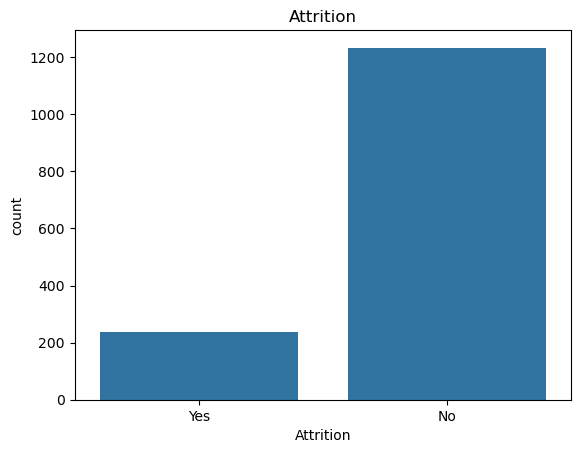

In [25]:
# Attritionsrate analysieren
print(f'Attritionsrate: {df['Attrition'].value_counts(normalize=True)*100}')
sns.countplot(data= df, x='Attrition')
plt.title('Attrition')
plt.show()

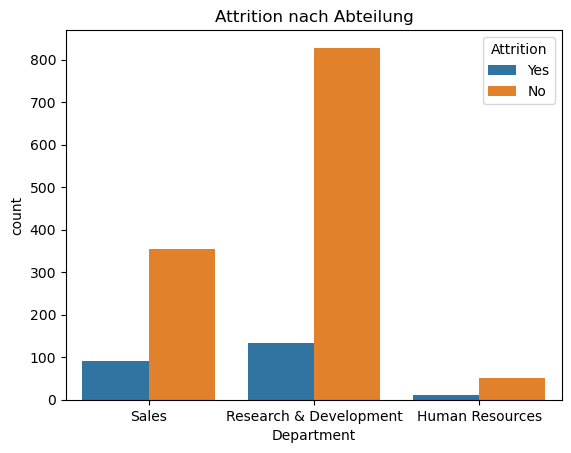

In [34]:
# Attrition nach Abteilung
sns.countplot(data=df, x= 'Department', hue= 'Attrition')
plt.title('Attrition nach Abteilung')
plt.show()

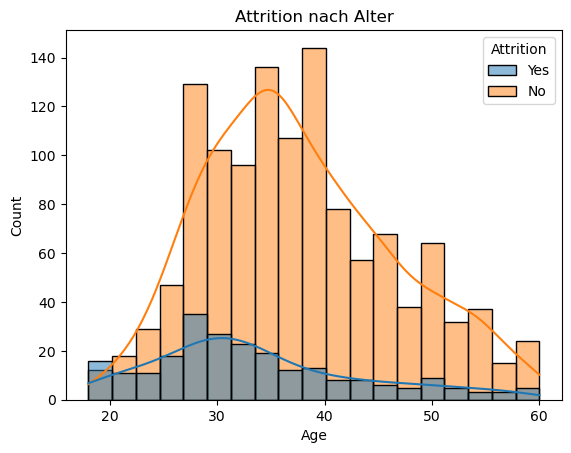

In [33]:
# Attrition nach Alter
sns.histplot(data=df, x='Age', hue='Attrition', kde=True)
plt.title('Attrition nach Alter')
plt.show()

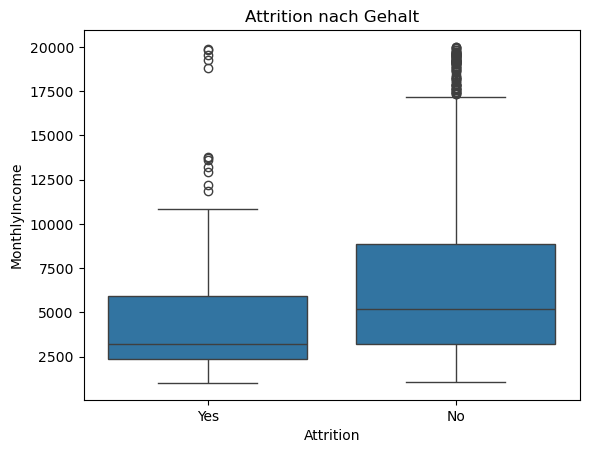

In [35]:
# Attrition nach Gehalt (MonthlyIncome)
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome')
plt.title('Attrition nach Gehalt')
plt.show()

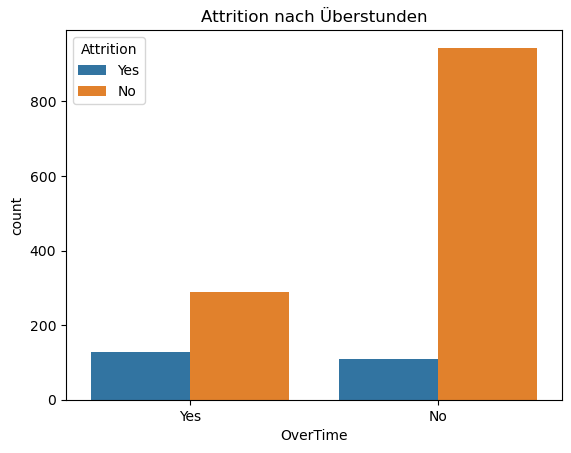

In [37]:
# Attrition nach Überstunden (Over Time)
sns.countplot(data=df, x='OverTime', hue= 'Attrition' )
plt.title('Attrition nach Überstunden')
plt.show()

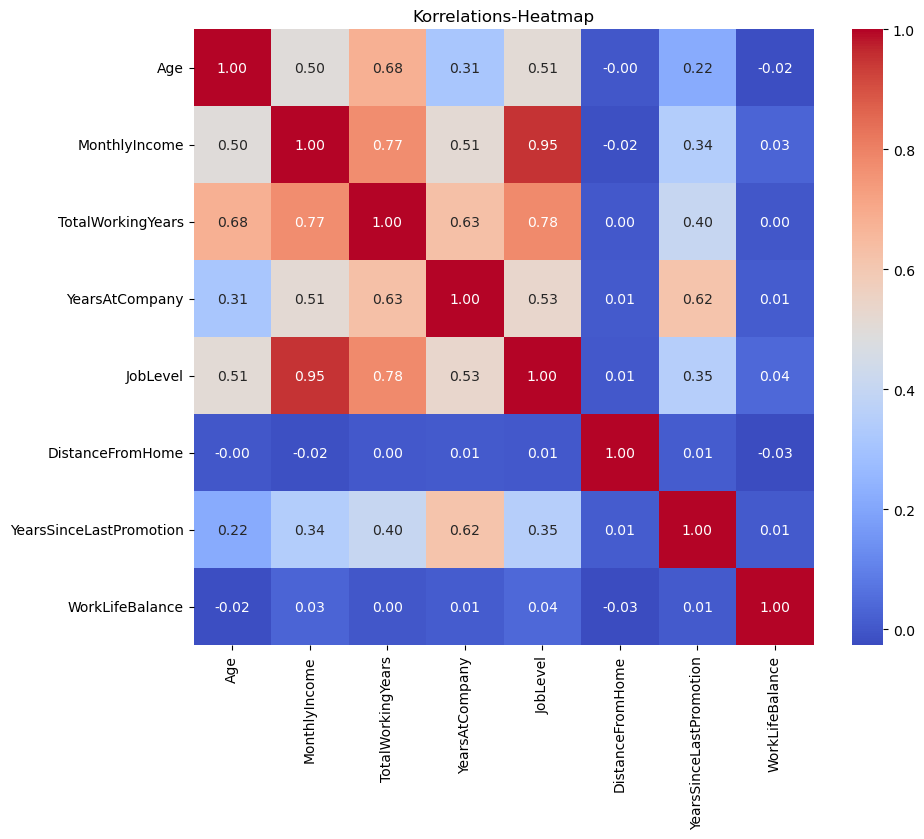

In [39]:
# Korrelations-Heatmap numerischer Merkmale
cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 
        'YearsAtCompany', 'JobLevel', 'DistanceFromHome',
        'YearsSinceLastPromotion', 'WorkLifeBalance']

num_cor = df[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(data=num_cor, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korrelations-Heatmap')
plt.show()

<Axes: xlabel='MonthlyIncome', ylabel='JobRole'>

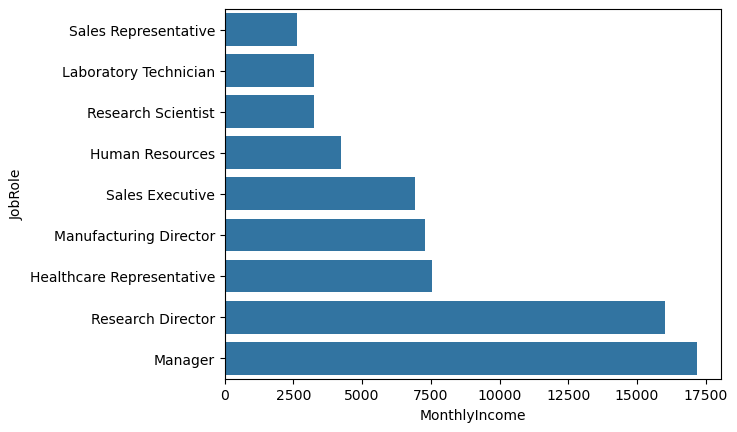

In [48]:
# Durchschnittliches Gehalt nach Jobrolle
mid_income = df.groupby('JobRole', as_index=False)['MonthlyIncome'].mean().sort_values('MonthlyIncome', ascending=True)
sns.barplot(data= mid_income, y='JobRole', x='MonthlyIncome')